In [41]:
import re 
import torch 
import torch.nn as nn 
import torch.optim as optim 
from collections import Counter 
from torch.utils.data import Dataset, DataLoader  
from transformers import AutoTokenizer, AutoModelForSequenceClassification 
from datasets import load_dataset 
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report 

In [42]:
raw = load_dataset("tasksource/jigsaw_toxicity")
print(raw)

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
})


In [43]:
full = raw['train'] 

split_1 = full.train_test_split(test_size = 0.2, seed = 42)
train_raw = split_1['train']
temp = split_1['test']

split_2 = temp.train_test_split(test_size = 0.5, seed = 42)
val_raw = split_2['train']
test_raw = split_2['test']

print(f"Train: {len(train_raw)} | Validation: {len(val_raw)} | Test: {len(test_raw)}")

Train: 127656 | Validation: 15957 | Test: 15958


In [44]:
print(train_raw)

Dataset({
    features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
    num_rows: 127656
})


In [45]:
print(train_raw.features)

{'id': Value('string'), 'comment_text': Value('string'), 'toxic': Value('int64'), 'severe_toxic': Value('int64'), 'obscene': Value('int64'), 'threat': Value('int64'), 'insult': Value('int64'), 'identity_hate': Value('int64')}


In [46]:
print(train_raw[0])

{'id': 'ae575164d0fdadb3', 'comment_text': "Missing Champions \n\nThis article should have ALL the TNA World Heavyweight Champions, from Ken Shamrock. Weird that it doesn't.", 'toxic': 0, 'severe_toxic': 0, 'obscene': 0, 'threat': 0, 'insult': 0, 'identity_hate': 0}


In [48]:
# CLASS IMBALANCE 
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
for label in labels: 
    label_count = Counter(train_raw[label])
    for k, v in label_count.items():
        print(f"{label} {k}: {v} ({v/len(train_raw)*100:.2f}%)")

toxic 0: 115380 (90.38%)
toxic 1: 12276 (9.62%)
severe_toxic 0: 126360 (98.98%)
severe_toxic 1: 1296 (1.02%)
obscene 0: 120883 (94.69%)
obscene 1: 6773 (5.31%)
threat 0: 127265 (99.69%)
threat 1: 391 (0.31%)
insult 0: 121349 (95.06%)
insult 1: 6307 (4.94%)
identity_hate 0: 126519 (99.11%)
identity_hate 1: 1137 (0.89%)


In [49]:
# EMPTY OR SHORT COMMENTS 
texts = train_raw['comment_text'] 
empty_or_short = sum(1 for text in texts if len(text) <= 20)
print(f"Empty or short comments: {empty_or_short} ({empty_or_short/len(texts)*100:.2f}%)")

Empty or short comments: 448 (0.35%)


In [50]:
# Duplicates 
duplicates = len(train_raw['comment_text']) - len(set(train_raw['comment_text']))
print(f"Duplicate comments: {duplicates} ({duplicates/len(texts)*100:.2f}%)")

Duplicate comments: 0 (0.00%)


In [70]:
# Html tags
html_tags = re.compile(r'<[a-z]+[^>]*>', re.IGNORECASE)

html_counts = sum(1 for t in texts if html_tags.search(str(t)))
print(f"Comments with HTML tags: {html_counts} ({html_counts/len(texts)*100:.2f}%)")

Comments with HTML tags: 0 (0.00%)


In [52]:
# Length of comments
lengths = [len(t.split()) for t in texts]
print(f"MIN_LENGTH: {min(lengths)} | MAX_LENGTH: {max(lengths)} | AVG_LENGTH: {sum(lengths)/len(lengths):.2f}")

MIN_LENGTH: 1 | MAX_LENGTH: 1411 | AVG_LENGTH: 67.30


In [83]:
import re

texts = train_raw['comment_text']

# URL sayı
urls = sum(1 for t in texts if re.search(r'http\S+|www\.\S+', t))
print(f"URL count : {urls} ({urls/len(texts)*100:.2f}%)")

# Email sayı
emails = sum(1 for t in texts if re.search(r'\S+@\S+', t))
print(f"Email count : {emails} ({emails/len(texts)*100:.2f}%)")

URL count : 4031 (3.16%)
Email count : 496 (0.39%)


50%: 36
95%: 230
99%: 571


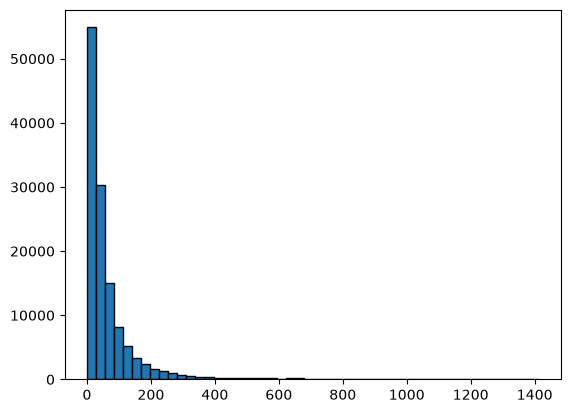

In [80]:
import numpy as np
import matplotlib.pyplot as plt

word_lengths = np.array([len(t.split()) for t in texts])

print(f"50%: {np.percentile(word_lengths, 50):.0f}")
print(f"95%: {np.percentile(word_lengths, 95):.0f}")
print(f"99%: {np.percentile(word_lengths, 99):.0f}")

plt.hist(word_lengths, bins=50, edgecolor = 'black')
plt.show()

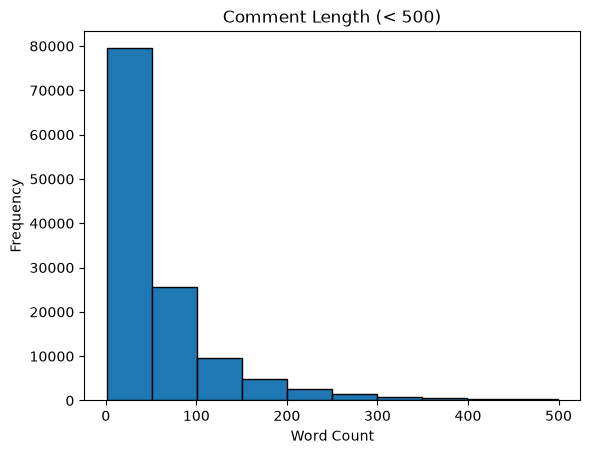

In [82]:
plt.hist(word_lengths[word_lengths < 500], edgecolor='black')
plt.title("Comment Length (< 500)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()